In [3]:
pip install spacy gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 1.7 MB/s eta 0:00:15
   -- ------------------------------------- 1.3/24.4 MB 3.1 MB/s eta 0:00:08
   ---- ----------------------------------- 2.6/24.4 MB 4.1 MB/s eta 0:00:06
   ------ --------------------------------- 3.7/24.4 MB 4.7 MB/s eta 0:00:05
   ------- -------------------------------- 4.7/24.4 MB 5.2 MB/s eta 0:00:04
   ---------- ----------------------------- 6.6/24.4 MB 5.4 MB/s eta 0:00:04
   ------------ --------------------------- 7.9/24.4 MB 5.7 MB/s eta 0:00:03
   -------------- ------------------------- 8.9/24.4 MB 5.8 MB/s eta 0:00:03
   ------------------ --------------------- 11.5/24.4 MB 6.5 MB/s eta 0:00:02
   --------------------- ------------------ 13.1/24.4 MB 6.5 MB/s eta 0:00:02
   ---------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import os
import csv
import spacy

class Corpus(object):
  def __init__(self,filename):
    self.filename=filename
    self.nlp=spacy.blank("en")

  def __iter__(self):
    with open(self.filename, "r", encoding="utf-8") as i:
      reader=csv.reader(i,delimiter=",")
      for _, abstract in reader:
        tokens = [t.text.lower() for t in self.nlp(abstract)]
        yield tokens

documents = Corpus(r"D:\AGENTICAI\arxiv.csv")
    



In [12]:
documents=list(documents)
documents[:5]

[['this',
  'paper',
  'investigates',
  'a',
  'cross',
  '-',
  'lingual',
  'document',
  'embedding',
  'method',
  'that',
  '\n',
  'improves',
  'the',
  'current',
  'neural',
  'machine',
  'translation',
  'framework',
  'based',
  'document',
  'vector',
  '\n',
  '(',
  'ntdv',
  'or',
  'simply',
  'nv',
  ')',
  '.',
  'nv',
  'is',
  'developed',
  'with',
  'a',
  'self',
  '-',
  'attention',
  'mechanism',
  'under',
  'the',
  '\n',
  'neural',
  'machine',
  'translation',
  '(',
  'nmt',
  ')',
  'framework',
  '.',
  'in',
  'nv',
  ',',
  'each',
  'pair',
  'of',
  'parallel',
  '\n',
  'documents',
  'in',
  'different',
  'languages',
  'are',
  'projected',
  'to',
  'the',
  'same',
  'shared',
  'layer',
  'in',
  'the',
  '\n',
  'model',
  '.',
  'however',
  ',',
  'the',
  'pair',
  'of',
  'nv',
  'embeddings',
  'are',
  'not',
  'guaranteed',
  'to',
  'be',
  'similar',
  '.',
  '\n',
  'this',
  'paper',
  'further',
  'adds',
  'a',
  'distance',


In [13]:
import gensim
model = gensim.models.Word2Vec( documents, min_count=100, window=5, vector_size=100)

In [14]:
model.wv["nlp"]

array([ 0.01951369, -1.7022338 ,  0.4304555 , -1.7134658 ,  0.13731791,
        0.7684715 ,  1.5023193 ,  0.93089926,  0.06759884,  1.912111  ,
       -0.96097106, -0.973971  ,  2.4949157 , -0.5920093 , -0.04730402,
       -0.3357748 , -0.3493639 ,  1.7355669 ,  0.3572513 ,  1.0261561 ,
        1.5764517 ,  0.5679413 , -0.16232122, -0.79313964, -1.987998  ,
       -2.5293593 ,  1.6721847 ,  0.5425601 ,  1.9596839 ,  0.8246904 ,
        1.0916396 ,  0.56589526,  1.5376668 ,  2.054736  , -0.15230985,
       -0.24011295,  0.8777896 , -5.1289153 , -0.48676157,  2.390761  ,
       -0.49791074, -1.6067314 ,  1.335494  ,  2.4262338 , -1.18272   ,
       -0.61674815,  0.6860747 ,  0.79479563, -0.39359316, -3.1153982 ,
        1.3578768 ,  0.7500676 ,  0.81201017, -0.22704428,  0.889853  ,
       -0.3380852 ,  0.50134873,  0.65690327,  3.9427452 , -0.6849234 ,
        0.12723193,  2.6099017 , -2.03224   , -1.2747489 ,  1.309648  ,
        0.60009146, -0.6493104 , -2.5643668 ,  0.18420132, -0.01

In [15]:
print(model.wv.similarity("same","now"))

0.043515034


In [16]:
model.wv.similar_by_word("bert",topn=10)
                         

[('roberta', 0.7753676772117615),
 ('transformer', 0.7725581526756287),
 ('pretrained', 0.7141039967536926),
 ('transformers', 0.7105197310447693),
 ('xlm', 0.6804779767990112),
 ('elmo', 0.6795684695243835),
 ('mbert', 0.6627017855644226),
 ('gpt-2', 0.6498635411262512),
 ('xlnet', 0.6351552605628967),
 ('lstm', 0.6119826436042786)]

In [17]:
model.wv.most_similar(positive="tree",topn=10)

[('trees', 0.7982819080352783),
 ('parse', 0.7163335084915161),
 ('constituency', 0.7010508179664612),
 ('recursive', 0.6805735230445862),
 ('dependency', 0.642062246799469),
 ('constituent', 0.6279569864273071),
 ('hierarchical', 0.5953921675682068),
 ('grammars', 0.5916613936424255),
 ('path', 0.5838369131088257),
 ('syntax', 0.583354115486145)]

In [20]:
model.wv.doesnt_match("lstm cnn gru svm transformer".split())

'svm'

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.manifold import TSNE

target_word = "bert"
selected_words = [w[0] for w in model.wv.most_similar(positive=[target_word],topn=200)] + [target_word]
embeddings = [model.wv[word] for word in selected_words]  + model.wv[target_word]

mapped_embeddings=TSNE(n_components=2,metric='cosine',init='pca', perplexity=5).fit_transform(np.vstack(embeddings))



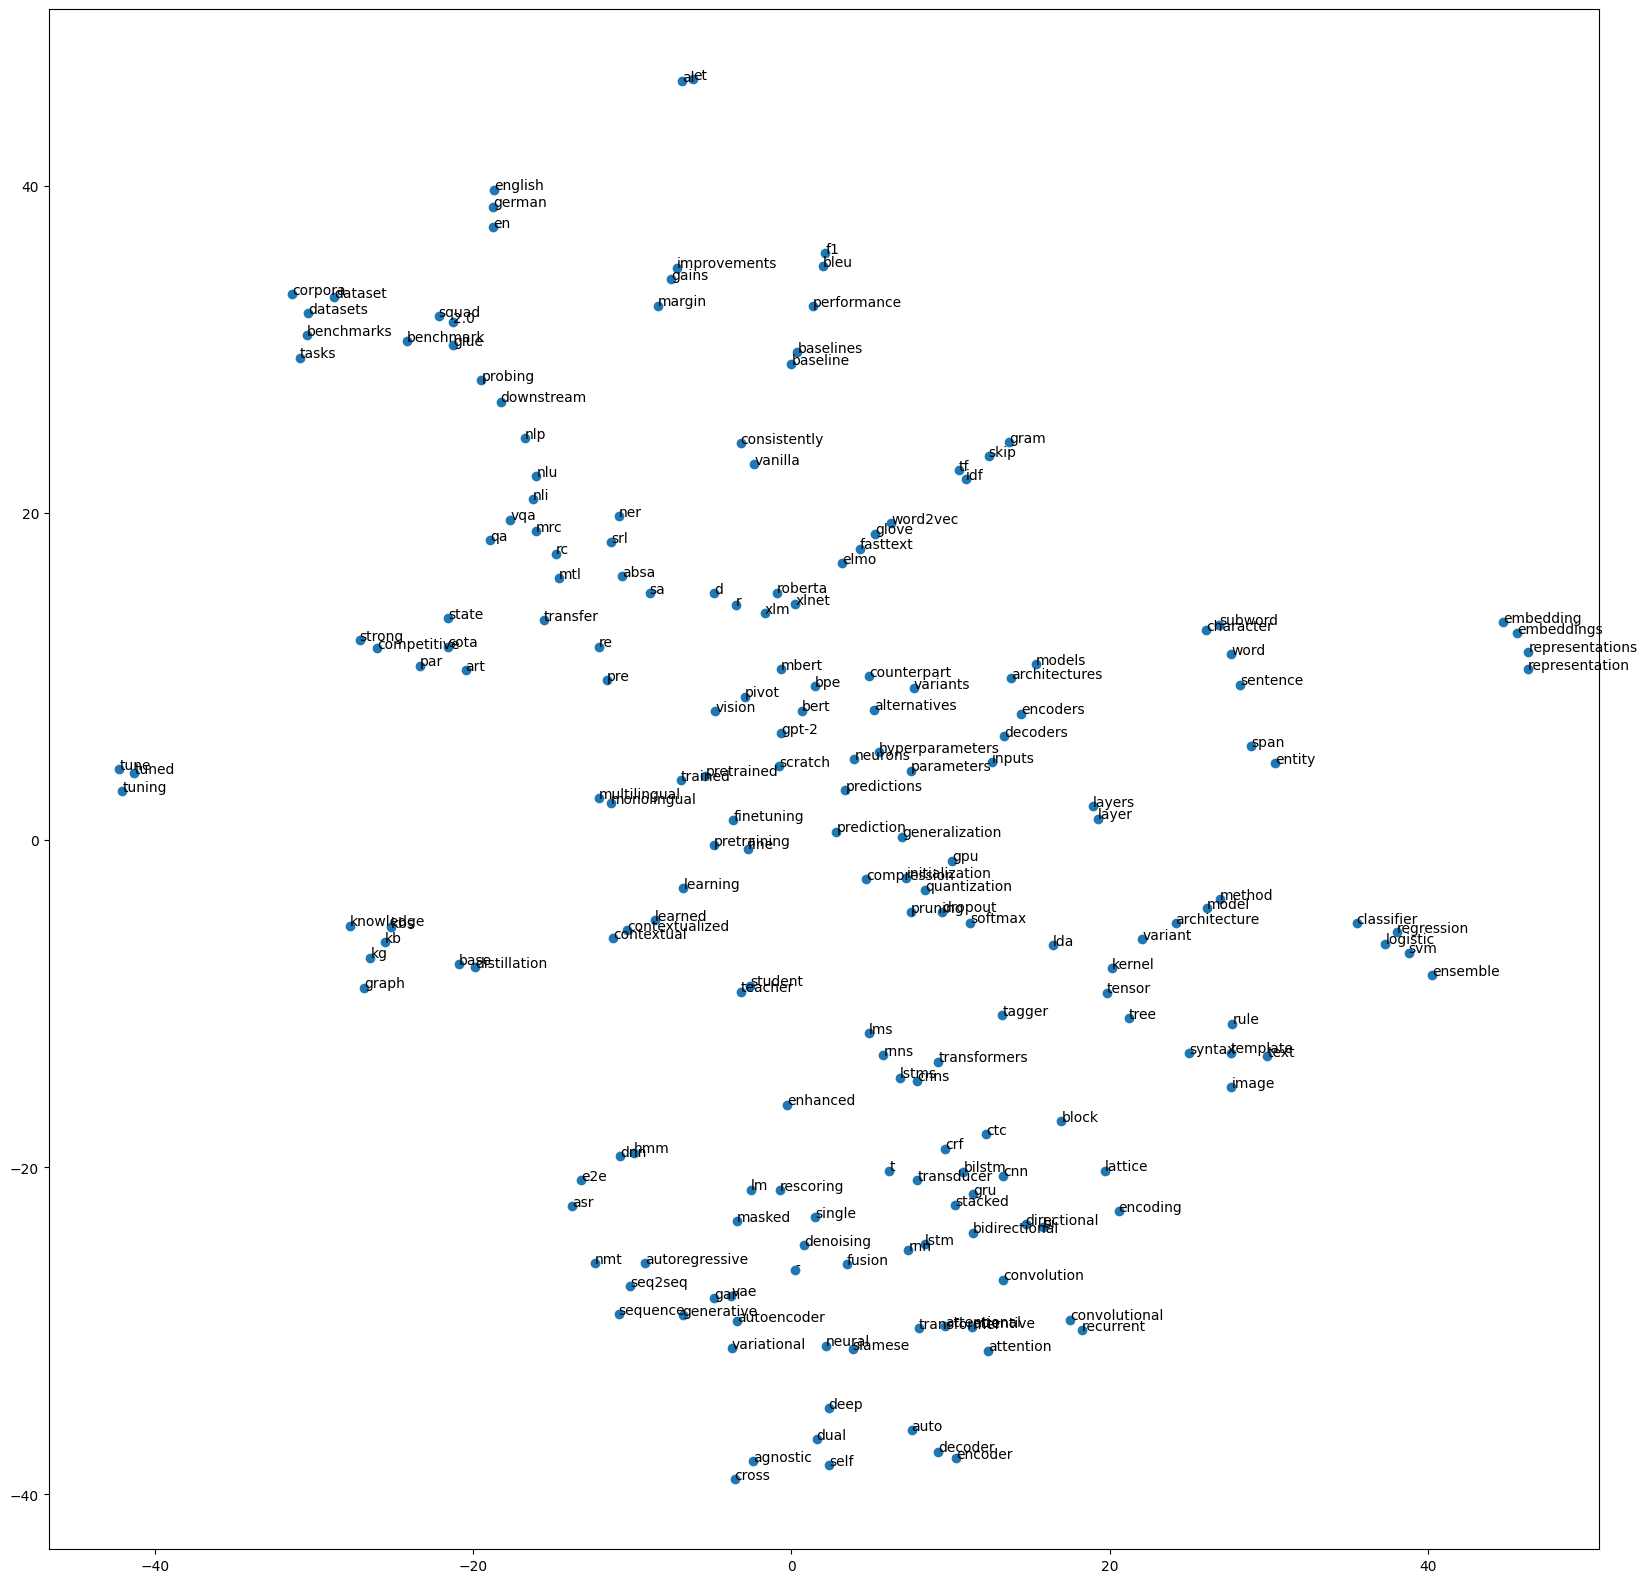

In [22]:
plt.figure(figsize=(20,20))
x=mapped_embeddings[:,0]
y=mapped_embeddings[:,1]
plt.scatter(x,y)

for i,txt in enumerate(selected_words):
  plt.annotate(txt,(x[i],y[i]))